In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

In [16]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# **Feature selection**

In [18]:
# This is a NEW dataframe create a smaller dataset with only selected column
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "2ndFlrSF",
    "TotRmsAbvGrd",
    "LotArea"
]

target = "SalePrice"

df_model = df[features + [target]]
df_model.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,1stFlrSF,2ndFlrSF,TotRmsAbvGrd,LotArea,SalePrice
0,7,1710,2,856,2003,2,856,854,8,8450,208500
1,6,1262,2,1262,1976,2,1262,0,6,9600,181500
2,7,1786,2,920,2001,2,920,866,6,11250,223500
3,7,1717,3,756,1915,1,961,756,7,9550,140000
4,8,2198,3,1145,2000,2,1145,1053,9,14260,250000


In [19]:
df_model.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
YearBuilt,0
FullBath,0
1stFlrSF,0
2ndFlrSF,0
TotRmsAbvGrd,0
LotArea,0


# **Train/test split**

In [20]:
# x is the features and y is the target
X = df_model.drop("SalePrice", axis=1)
y = df_model["SalePrice"]

In [21]:
# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# create the model
model = LinearRegression()

In [23]:
# train the model
model.fit(X_train, y_train)

LinearRegression()

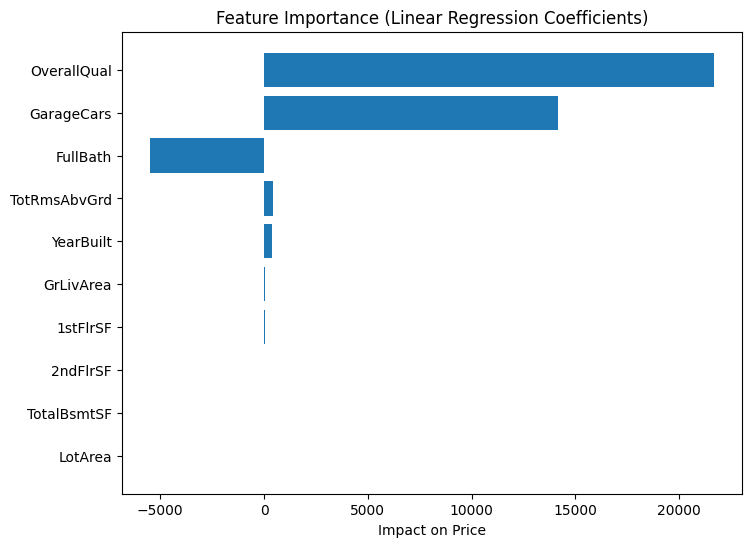

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.coef_
})

importance = importance.sort_values(by="Importance", key=np.abs, ascending=True)

plt.figure(figsize=(8,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Feature Importance (Linear Regression Coefficients)")
plt.xlabel("Impact on Price")
plt.show()

**Predictions**

In [24]:
y_pred = model.predict(X_test)

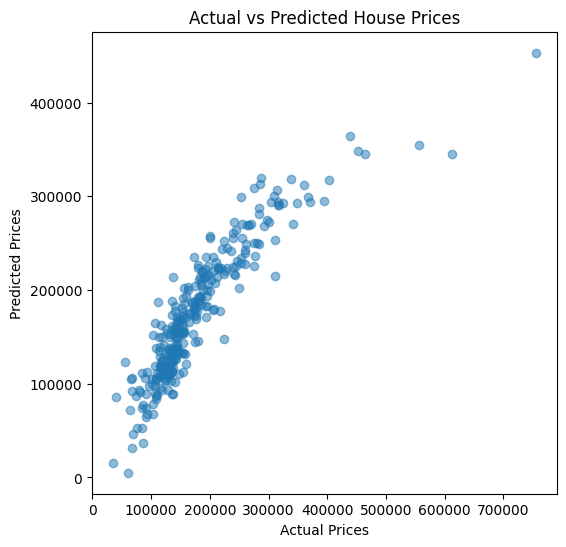

In [28]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

**Evaluate the Model**

In [25]:
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 39453.68691175006


In [26]:
predictions = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

predictions.head(10)

,Actual Price,Predicted Price
892,154500,144010.014860
1105,325000,293027.293741
413,115000,120091.590200
522,159000,170949.745871
1036,315500,290181.077204
614,75500,53272.363666
218,311500,214519.483548
1160,146000,167449.016699
649,84500,52809.802300
887,135500,134719.284700
